**Licenciatura en Ciencia de Datos — Inteligencia Artificial y Aprendizaje Automático I**

# Trabajo Práctico 2 — Algoritmos de Predicción y Evaluación de Modelos

**Predicción de la producción mensual de petróleo (`prod_pet`) de pozos de hidrocarburos**

Andrisani, Facundo · Feser, Ignacio · Lauria, Francisco · Viccei, Tomás — Pontificia Universidad Católica Argentina — 2026

---

**Modelo desplegable (→ TP4):** XGBoost sobre el **set estructural** de features, **optimizado por `GridSearchCV`** con validación cruzada agrupada por pozo, y serializado con `joblib`.

## A. Definición del marco experimental

**Problema de predicción (P7–P8 del TP1).** Estimar el volumen mensual de petróleo `prod_pet` (m³/mes) de un pozo a partir de sus características **técnicas, operativas y geográficas**. La relevancia práctica es directa: permite caracterizar el rendimiento esperado de un pozo según su configuración y ubicación, insumo para planificación de producción, priorización de intervenciones y estimación de reservas.

**Universo de modelado.** Se restringe a **pozos productores** (`prod_pet > 0`). El dataset del TP1 contiene ~70 % de registros con producción de petróleo nula (pozos inactivos o gasíferos); modelar sobre el total convierte el problema en uno de *exceso de ceros* (zero-inflated) que mezcla dos fenómenos distintos —producir o no, y cuánto—. Aislar la magnitud de producción sobre el subconjunto activo produce un target continuo limpio y alineado con la pregunta P7.

**Variable objetivo.** `prod_pet`, con **transformación `log1p`**: en el TP1 se documentó una asimetría severa (skewness ≈ 9); `log1p` la reduce a ≈ 0,1, condición necesaria para los modelos lineales y beneficiosa para todos. Se usa `TransformedTargetRegressor` para entrenar en escala logarítmica y **reportar las métricas en la escala original** (m³/mes) mediante `expm1`.

**Features — set estructural vs. co-producción.** El set **principal (estructural)** describe honestamente al pozo: `profundidad`, `mes`, `tipoextraccion`, `tipopozo`, `cuenca`, `provincia`, `tipo_de_recurso`. Se **excluyen** `prod_gas`, `prod_agua`, `iny_agua` y `tef` porque son fluidos **co-producidos contemporáneos** a `prod_pet` (medidos el mismo mes): usarlos para predecir la producción de petróleo del mismo período es circular y **no estarían disponibles** en el escenario de caracterización de un pozo (la aplicación del TP4). Su aporte se cuantifica aparte como *análisis de sensibilidad* (Sección I). También se excluyen `idpozo` (identificador, solo agrupa la partición), `anio` (constante), y `tipoestado`/`estado_binario` (etiquetas de estado, objetivo del TP3).

**Partición agrupada (previene *data leakage* de panel).** El dataset es un **panel**: cada pozo aparece repetido a lo largo de ~12 meses con valores muy correlacionados. Una partición aleatoria por filas dejaría el mismo pozo en *train* y *test*, y el modelo "adivinaría" usando información del propio pozo en lugar de generalizar. Se usa `GroupShuffleSplit` **agrupando por `idpozo`** (80/20, `random_state=42`), garantizando que ningún pozo aparezca en ambos conjuntos, y `GroupKFold` para la validación cruzada y la búsqueda de hiperparámetros.

**Baseline.** `Regresión Lineal` múltiple, punto de referencia mínimo frente al cual se contrastan los modelos de mayor complejidad.

**Modelo final (→ TP4).** El mejor modelo de la comparación (XGBoost) se **optimiza por `GridSearchCV`** con `GroupKFold` y se **adopta como modelo desplegable**, entrenado sobre el set estructural y serializado con `joblib`.

In [3]:
# ── Librerías ────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, os
from sklearn.model_selection import (GroupShuffleSplit, GroupKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .3})
RNG = 42
os.makedirs('figs', exist_ok=True)
print('Librerías cargadas. Semilla fija RNG =', RNG)

Librerías cargadas. Semilla fija RNG = 42


In [4]:
# ── A.1 Carga y definición del universo de modelado ──────────────────────────
df = pd.read_csv('dataset_tp1_procesado (1).csv')
print(f'Dataset TP1 completo: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# Universo: solo pozos productores de petróleo (prod_pet > 0)
sub = df[df['prod_pet'] > 0].copy()
print(f'Universo de modelado (prod_pet > 0): {sub.shape[0]:,} filas  '
      f'({len(sub)/len(df)*100:.1f}% del total) — {sub["idpozo"].nunique():,} pozos únicos')

# Justificación de la transformación log1p del target
print(f'\nAsimetría (skewness) de prod_pet : {sub["prod_pet"].skew():.2f}')
print(f'Asimetría de log1p(prod_pet)      : {np.log1p(sub["prod_pet"]).skew():.2f}')

Dataset TP1 completo: 872,186 filas × 16 columnas
Universo de modelado (prod_pet > 0): 264,580 filas  (30.3% del total) — 24,556 pozos únicos

Asimetría (skewness) de prod_pet : 9.09
Asimetría de log1p(prod_pet)      : 0.12


In [5]:
# ── A.2 Definición de conjuntos de variables ─────────────────────────────────
TARGET = 'prod_pet'
num_principal = ['profundidad']
cat_principal = ['mes', 'tipoextraccion', 'tipopozo', 'cuenca', 'provincia', 'tipo_de_recurso']
feat_principal = num_principal + cat_principal

# Excluidas del set principal (co-producción contemporánea → sensibilidad, Sección I)
num_coproduccion = ['prod_gas', 'prod_agua', 'iny_agua', 'tef']

print('FEATURES (set estructural — el que se despliega):')
print('  Numéricas  :', num_principal)
print('  Categóricas:', cat_principal)
print('\nEXCLUIDAS del set principal:')
print('  Co-producción (contemporánea):', num_coproduccion)
print('  Identificador / constante / target / etiquetas TP3:',
      ['idpozo', 'anio', 'tipoestado', 'estado_binario', 'prod_pet'])

FEATURES (set estructural — el que se despliega):
  Numéricas  : ['profundidad']
  Categóricas: ['mes', 'tipoextraccion', 'tipopozo', 'cuenca', 'provincia', 'tipo_de_recurso']

EXCLUIDAS del set principal:
  Co-producción (contemporánea): ['prod_gas', 'prod_agua', 'iny_agua', 'tef']
  Identificador / constante / target / etiquetas TP3: ['idpozo', 'anio', 'tipoestado', 'estado_binario', 'prod_pet']


In [6]:
# ── B. Partición agrupada por pozo (previene leakage de panel) ───────────────
X = sub[feat_principal].copy()
y = sub[TARGET].values
groups = sub['idpozo'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RNG)
idx_tr, idx_te = next(gss.split(X, y, groups))

pozos_tr, pozos_te = set(groups[idx_tr]), set(groups[idx_te])
print(f'Train: {len(idx_tr):,} filas | {len(pozos_tr):,} pozos')
print(f'Test : {len(idx_te):,} filas | {len(pozos_te):,} pozos')
print(f'Pozos compartidos train∩test: {len(pozos_tr & pozos_te)}  (debe ser 0 → sin leakage de panel)')

Train: 211,642 filas | 19,644 pozos
Test : 52,938 filas | 4,912 pozos
Pozos compartidos train∩test: 0  (debe ser 0 → sin leakage de panel)


In [7]:
# ── C. Preprocesamiento y fábrica de pipelines ───────────────────────────────
# RobustScaler (mediana/IQR) en numéricas por la asimetría; OneHot en categóricas.
# El preprocesamiento se ajusta SOLO sobre train dentro de cada Pipeline (sin leakage).
def preprocesador(num, cat):
    return ColumnTransformer([
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)])

def construir(reg, num, cat):
    # TransformedTargetRegressor: entrena en log1p, predice en escala original (m³/mes)
    pipe = Pipeline([('pre', preprocesador(num, cat)), ('modelo', reg)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

# Dimensionalidad tras one-hot (para R² ajustado)
p_feat = preprocesador(num_principal, cat_principal).fit(X.iloc[idx_tr]).transform(X.iloc[idx_tr]).shape[1]
print(f'Nº de predictores tras one-hot (set estructural): {p_feat}')

Nº de predictores tras one-hot (set estructural): 49


## D. Modelos e hiperparámetros

Se implementan **seis algoritmos**, superando el mínimo de tres. Cada uno se envuelve en el `Pipeline` (preprocesamiento + `log1p`) descrito arriba.

| Modelo | Rol | Hiperparámetros | n_train |
|---|---|---|---|
| `LinearRegression` | Baseline | Default | 211 k (completo) |
| `Ridge` | Lineal regularizado (L2) | `alpha=1.0` | 211 k (completo) |
| `Lasso` | Lineal regularizado (L1) | `alpha=0.01` | 211 k (completo) |
| `RandomForestRegressor` | Ensamble (bagging) | `n_estimators=100`, `max_depth=20` | 30 k (submuestra) |
| `KNeighborsRegressor` | Basado en instancias | `n_neighbors=15`, `weights='distance'` | 30 k (submuestra) |
| `XGBRegressor` | Ensamble (boosting) | `n_estimators=300`, `max_depth=6`, `lr=0.1`, `subsample=0.9` | 211 k (completo) |

> **Nota sobre `n_train`.** Random Forest y KNN escalan mal con ~212 k filas, por lo que se entrenan sobre una **submuestra de 30 k** del train (documentada en la tabla). Esto debe tenerse en cuenta al leer su brecha *train-test*: parte de su sobreajuste aparente también refleja que disponen de ~7× menos datos que XGBoost y los lineales. La conclusión (XGBoost como mejor modelo) es robusta porque XGBoost se entrena con el **mismo volumen** que los lineales.

In [8]:
# ── D.1 Entrenamiento de los modelos ─────────────────────────────────────────
# KNN y Random Forest escalan mal con ~212k filas: se entrenan sobre una submuestra
# representativa del train (documentada en la tabla como n_train). El resto usa todo train.
rng = np.random.RandomState(RNG)
idx_sample = rng.choice(idx_tr, size=30000, replace=False)

modelos = {
    'Regresión Lineal': (LinearRegression(),                                              'full'),
    'Ridge (L2)':       (Ridge(alpha=1.0, random_state=RNG),                              'full'),
    'Lasso (L1)':       (Lasso(alpha=0.01, random_state=RNG),                             'full'),
    'Random Forest':    (RandomForestRegressor(n_estimators=100, max_depth=20,
                                               n_jobs=-1, random_state=RNG),              'sample'),
    'KNN (k=15)':       (KNeighborsRegressor(n_neighbors=15, weights='distance', n_jobs=-1),'sample'),
    'XGBoost':          (XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                      subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                                      random_state=RNG, tree_method='hist'),              'full'),
}

fitted, pred_tr, pred_te, n_train = {}, {}, {}, {}
for nombre, (reg, modo) in modelos.items():
    tr = idx_tr if modo == 'full' else idx_sample
    m = construir(reg, num_principal, cat_principal)
    m.fit(X.iloc[tr], y[tr])
    fitted[nombre]  = m
    pred_tr[nombre] = m.predict(X.iloc[tr]); pred_te[nombre] = m.predict(X.iloc[idx_te])
    n_train[nombre] = len(tr)
    y_tr = y[tr]
    print(f'{nombre:18s} n_train={len(tr):>6,}  '
          f'R²_train={r2_score(y_tr, pred_tr[nombre]):.3f}  R²_test={r2_score(y[idx_te], pred_te[nombre]):.3f}')

Regresión Lineal   n_train=211,642  R²_train=0.263  R²_test=0.243
Ridge (L2)         n_train=211,642  R²_train=0.263  R²_test=0.243
Lasso (L1)         n_train=211,642  R²_train=0.232  R²_test=0.212
Random Forest      n_train=30,000  R²_train=0.779  R²_test=0.405
KNN (k=15)         n_train=30,000  R²_train=0.988  R²_test=0.408
XGBoost            n_train=211,642  R²_train=0.489  R²_test=0.453


In [9]:
# ── E. Tabla comparativa consolidada (train vs test) ─────────────────────────
def metricas(yt, yp, p):
    yt = np.asarray(yt); yp = np.asarray(yp)
    n = len(yt); r2 = r2_score(yt, yp)
    r2a = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mask = yt > 10                                   # MAPE robusto: evita denominadores ~0
    mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100
    return {'RMSE': mean_squared_error(yt, yp) ** 0.5,
            'MAE':  mean_absolute_error(yt, yp),
            'R2':   r2, 'R2_adj': r2a, 'MAPE': mape}

filas = []
for nombre in modelos:
    tr = idx_tr if modelos[nombre][1] == 'full' else idx_sample
    mtr = metricas(y[tr], pred_tr[nombre], p_feat)
    mte = metricas(y[idx_te], pred_te[nombre], p_feat)
    filas.append({'Modelo': nombre, 'n_train': n_train[nombre],
                  'RMSE_train': mtr['RMSE'], 'RMSE_test': mte['RMSE'],
                  'MAE_train':  mtr['MAE'],  'MAE_test':  mte['MAE'],
                  'R2_train':   mtr['R2'],   'R2_test':   mte['R2'],
                  'R2adj_test': mte['R2_adj'], 'MAPE_test': mte['MAPE']})

tabla = pd.DataFrame(filas).sort_values('R2_test', ascending=False).reset_index(drop=True)
tabla.to_csv('metricas_tp2.csv', index=False)
mejor = tabla.iloc[0]['Modelo']
print(f'Mejor modelo por R²_test: {mejor}\n')
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
display(tabla.round(3))

Mejor modelo por R²_test: XGBoost



,Modelo,n_train,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test,R2adj_test,MAPE_test
0,XGBoost,211642,402.930,436.329,98.755,105.506,0.489,0.453,0.452,71.705
1,KNN (k=15),30000,64.720,453.900,9.698,116.050,0.988,0.408,0.407,91.795
2,Random Forest,30000,279.254,455.163,64.480,112.753,0.779,0.405,0.404,82.435
3,Ridge (L2),211642,483.684,513.349,118.282,120.008,0.263,0.243,0.242,74.915
4,Regresión Lineal,211642,483.703,513.368,118.287,120.019,0.263,0.243,0.242,74.926
5,Lasso (L1),211642,493.685,523.462,120.917,122.329,0.232,0.212,0.212,72.812


> **Lectura de la tabla.** El **XGBoost** es el mejor modelo en las tres métricas de test (mayor R², menor RMSE y menor MAE). La **familia lineal** (Lineal ≈ Ridge ≈ Lasso) queda por detrás con R² ≈ 0,24 y una brecha train–test mínima: es un caso de **subajuste (alto sesgo)** — no captura las relaciones no lineales entre método de extracción, cuenca y producción. **Random Forest** y **KNN** exhiben la brecha opuesta: R²_train muy alto (0,78–0,99) frente a R²_test ≈ 0,40, señal de **sobreajuste (alta varianza)**. Dos matices honestos para interpretar bien esa brecha: (i) RF y KNN se entrenaron con **30 k filas** frente a las **211 k** de XGBoost y los lineales, de modo que parte de su brecha también refleja **menos datos**, no solo varianza del modelo; y (ii) aun así, XGBoost —entrenado con el mismo volumen que los lineales— logra el mejor **balance sesgo–varianza** (R²_train ≈ 0,49 vs R²_test ≈ 0,45, brecha pequeña). *Nota sobre MAPE:* se calcula solo sobre pozos con producción > 10 m³ para evitar la explosión del cociente en denominadores cercanos a cero; aun así RMSE/MAE son más confiables en este dominio y se usan como criterio.

## F. Optimización del modelo desplegable (XGBoost estructural)

El mejor modelo de la comparación se **optimiza por búsqueda de hiperparámetros** y se adopta como el **modelo definitivo que se desplegará en el TP4**. Tres decisiones metodológicas:

1. **Validación cruzada agrupada dentro de la búsqueda.** El `GridSearchCV` usa **`GroupKFold`** con `groups=idpozo`, de modo que la partición interna de la búsqueda respeta la estructura de panel (ningún pozo cae a la vez en el *fit* y la validación de un mismo *fold*). Usar un CV por filas aquí reintroduciría el *leakage* que la partición externa evita.
2. **`refit=True` sobre todo el train.** Elegidos los mejores hiperparámetros, `GridSearchCV` reentrena automáticamente el modelo sobre **todo** el conjunto de entrenamiento (`best_estimator_`); esa es la versión que se serializa y despliega.
3. **Paralelismo sin *oversubscription*.** XGBoost paraleliza internamente (`n_jobs=-1`); por eso el buscador usa `n_jobs=1`, evitando que ambos niveles compitan por los mismos núcleos y ralenticen el cómputo.

In [10]:
# ── F.1 GridSearchCV sobre XGBoost con validación cruzada AGRUPADA ───────────
xgb_grid = construir(
    XGBRegressor(subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                 random_state=RNG, tree_method='hist'),
    num_principal, cat_principal)

# Prefijo de parámetros: TransformedTargetRegressor → regressor (Pipeline) → modelo
param_grid = {
    'regressor__modelo__max_depth':     [4, 6, 8],
    'regressor__modelo__learning_rate': [0.05, 0.1],
    'regressor__modelo__n_estimators':  [400, 700],
}

grid = GridSearchCV(
    xgb_grid, param_grid,
    cv=GroupKFold(n_splits=3),
    scoring='r2', n_jobs=1, verbose=1, refit=True)

import time; t0 = time.time()
grid.fit(X.iloc[idx_tr], y[idx_tr], groups=groups[idx_tr])
print(f'\nGridSearch completado en {(time.time() - t0) / 60:.1f} min')
print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'R² CV (GroupKFold=3) del mejor candidato: {grid.best_score_:.3f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearch completado en 6.8 min
Mejores hiperparámetros: {'regressor__modelo__learning_rate': 0.05, 'regressor__modelo__max_depth': 8, 'regressor__modelo__n_estimators': 700}
R² CV (GroupKFold=3) del mejor candidato: 0.471


In [11]:
# ── F.2 Modelo final: XGBoost optimizado (ya reentrenado sobre TODO el train) ──
# grid.best_estimator_ fue reentrenado por refit=True sobre las 211k filas de train.
modelo_final = grid.best_estimator_
yhat_final   = modelo_final.predict(X.iloc[idx_te])

m_final = metricas(y[idx_te], yhat_final, p_feat)
m_xgb_def = tabla.set_index('Modelo').loc['XGBoost']

print('MODELO FINAL — XGBoost estructural optimizado (se despliega en el TP4)')
print(f'  R²_test  : {m_xgb_def["R2_test"]:.3f}  →  {m_final["R2"]:.3f}   (XGB por defecto → optimizado)')
print(f'  RMSE_test: {m_xgb_def["RMSE_test"]:.2f}  →  {m_final["RMSE"]:.2f} m³/mes')
print(f'  MAE_test : {m_xgb_def["MAE_test"]:.2f}  →  {m_final["MAE"]:.2f} m³/mes')

# Confirmación de estabilidad: el R² CV agrupado ≈ R² hold-out → no hay sobreajuste al split
print(f'\n  R² CV (GroupKFold) : {grid.best_score_:.3f}')
print(f'  R² hold-out (test) : {m_final["R2"]:.3f}  → consistentes')

# ── Serialización para el TP4 (ColumnTransformer + log1p + modelo, en un objeto) ──
joblib.dump(modelo_final, 'modelo_prod_pet_xgboost.joblib')
tam = os.path.getsize('modelo_prod_pet_xgboost.joblib') / 1e6
print(f'\nModelo serializado: modelo_prod_pet_xgboost.joblib ({tam:.1f} MB)')
print('→ Incluye preprocesamiento + transformación log1p → listo para el TP4 sin reentrenar.')

MODELO FINAL — XGBoost estructural optimizado (se despliega en el TP4)
  R²_test  : 0.453  →  0.459   (XGB por defecto → optimizado)
  RMSE_test: 436.33  →  433.98 m³/mes
  MAE_test : 105.51  →  105.84 m³/mes

  R² CV (GroupKFold) : 0.471
  R² hold-out (test) : 0.459  → consistentes

Modelo serializado: modelo_prod_pet_xgboost.joblib (8.0 MB)
→ Incluye preprocesamiento + transformación log1p → listo para el TP4 sin reentrenar.


## G. Diagnóstico visual del modelo final

Se generan las visualizaciones exigidas y se diagnostica el **modelo final optimizado**: (1) comparación de métricas por modelo, (2) predicho-vs-real, (3) análisis de residuos, incluyendo una versión **avanzada** (test de normalidad de Shapiro-Wilk, Q-Q plot y verificación de homocedasticidad).

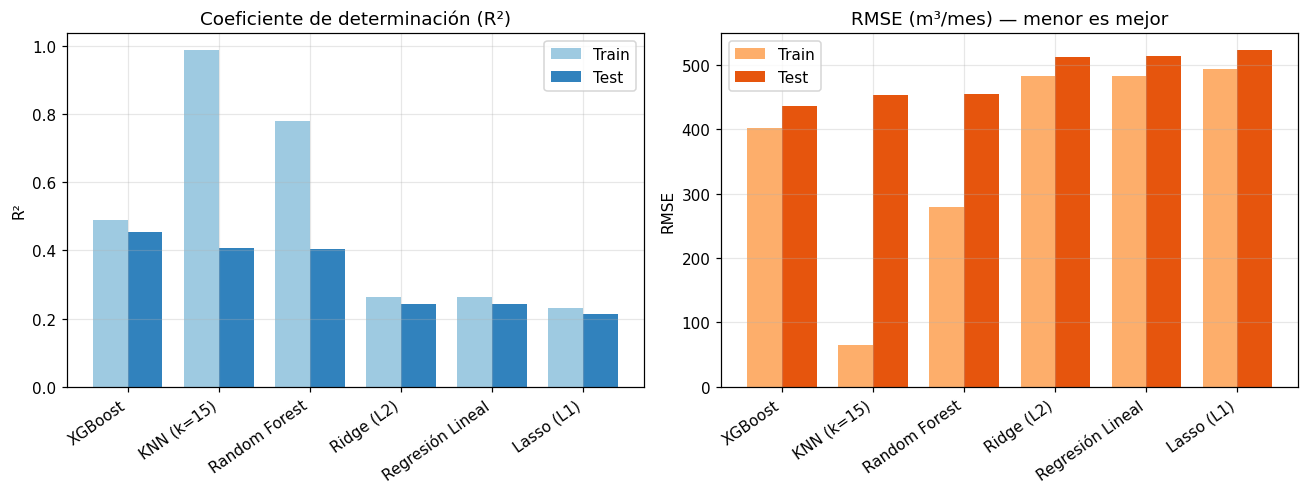

In [12]:
# ── G.1 Comparación visual de métricas (R² y RMSE, train vs test) ────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
orden = tabla['Modelo'].tolist(); xpos = np.arange(len(orden)); w = 0.38

ax[0].bar(xpos-w/2, tabla['R2_train'], w, label='Train', color='#9ecae1')
ax[0].bar(xpos+w/2, tabla['R2_test'],  w, label='Test',  color='#3182bd')
ax[0].set_title('Coeficiente de determinación (R²)'); ax[0].set_ylabel('R²')
ax[0].set_xticks(xpos); ax[0].set_xticklabels(orden, rotation=35, ha='right'); ax[0].legend()

ax[1].bar(xpos-w/2, tabla['RMSE_train'], w, label='Train', color='#fdae6b')
ax[1].bar(xpos+w/2, tabla['RMSE_test'],  w, label='Test',  color='#e6550d')
ax[1].set_title('RMSE (m³/mes) — menor es mejor'); ax[1].set_ylabel('RMSE')
ax[1].set_xticks(xpos); ax[1].set_xticklabels(orden, rotation=35, ha='right'); ax[1].legend()
plt.tight_layout(); plt.savefig('figs/fig1_comparacion_metricas.png', bbox_inches='tight'); plt.show()

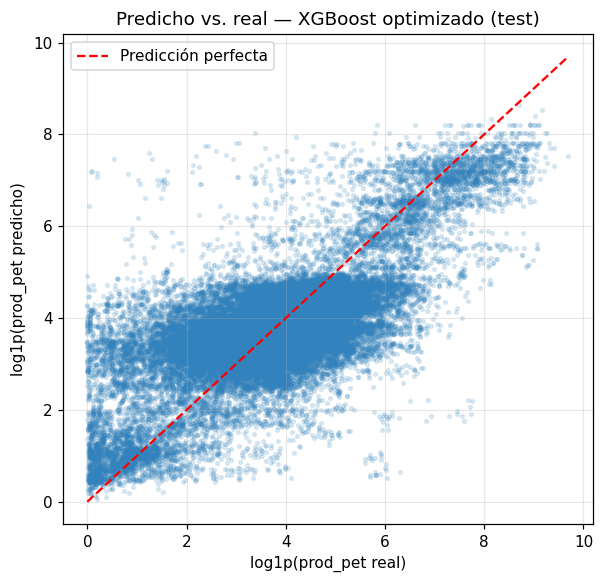

In [13]:
# ── G.2 Predicho vs. real del MODELO FINAL (escala log1p por la asimetría) ────
yte = y[idx_te]; yhat = yhat_final
fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.scatter(np.log1p(yte), np.log1p(yhat), s=6, alpha=0.15, color='#3182bd')
lims = [0, np.log1p(yte).max()]
ax.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('log1p(prod_pet real)'); ax.set_ylabel('log1p(prod_pet predicho)')
ax.set_title('Predicho vs. real — XGBoost optimizado (test)'); ax.legend()
plt.tight_layout(); plt.savefig('figs/fig2_predicho_vs_real.png', bbox_inches='tight'); plt.show()

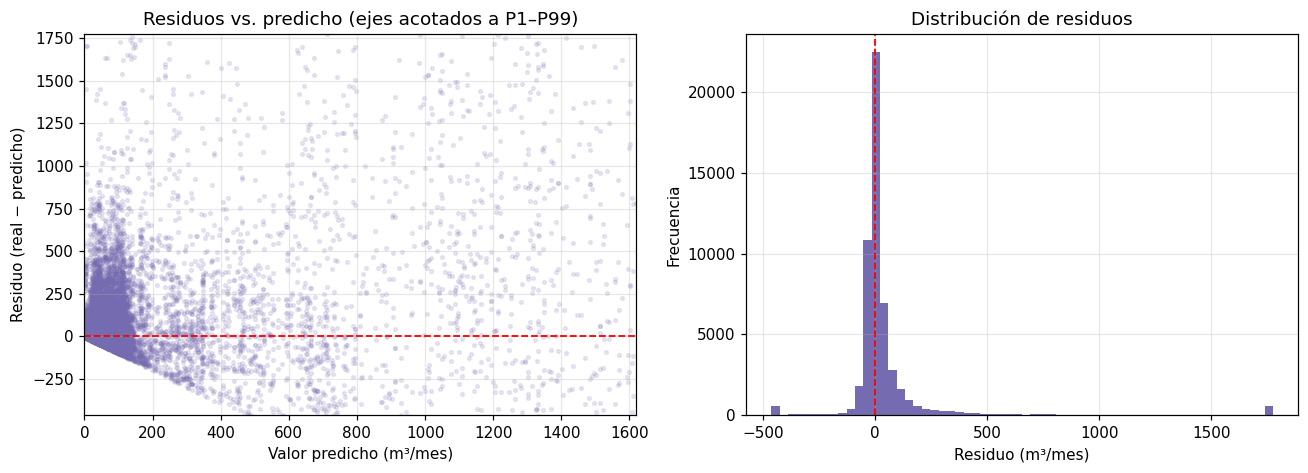

Análisis de residuos avanzado (modelo final):
  Media : 59.37 | Mediana: 0.60 m³/mes
  Desvío: 429.90 | Skew: 9.61 | Curtosis: 142.33
  Shapiro-Wilk p = 5.29e-89  (p<0.05 → residuos NO normales)


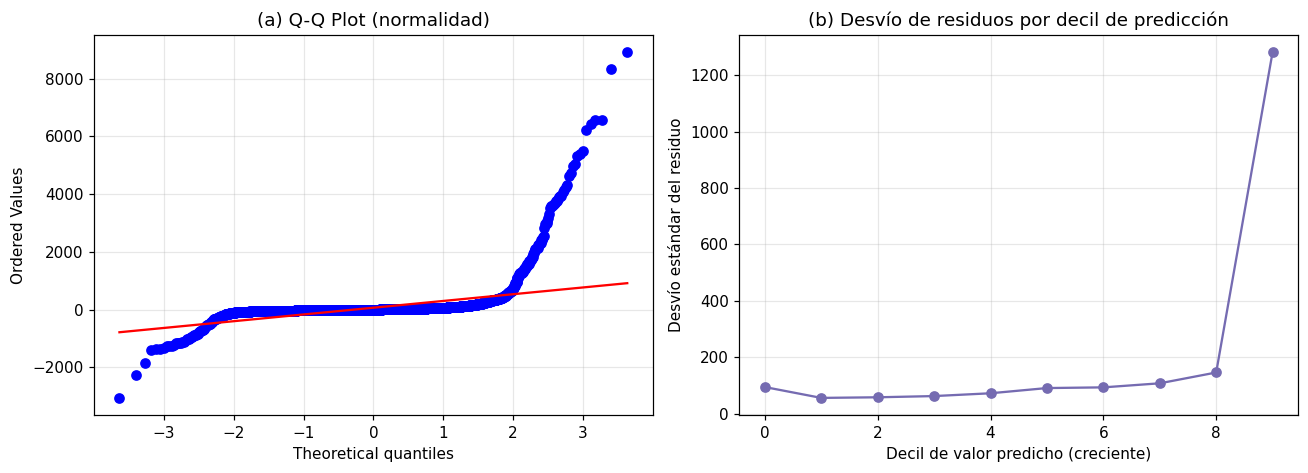


  → Si el desvío crece con el decil de predicción, hay HETEROCEDASTICIDAD.


In [14]:
# ── G.3 Análisis de residuos del modelo final (básico + avanzado) ────────────
from scipy import stats
resid = yte - yhat

# (básico) Residuos vs. predicho + distribución
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
lim = np.percentile(yhat, 99)
ax[0].scatter(yhat, resid, s=6, alpha=0.15, color='#756bb1')
ax[0].axhline(0, color='r', ls='--', lw=1.2)
ax[0].set_xlim(0, lim); ax[0].set_ylim(np.percentile(resid,1), np.percentile(resid,99))
ax[0].set_xlabel('Valor predicho (m³/mes)'); ax[0].set_ylabel('Residuo (real − predicho)')
ax[0].set_title('Residuos vs. predicho (ejes acotados a P1–P99)')
ax[1].hist(np.clip(resid, np.percentile(resid,1), np.percentile(resid,99)), bins=60, color='#756bb1')
ax[1].axvline(0, color='r', ls='--', lw=1.2)
ax[1].set_xlabel('Residuo (m³/mes)'); ax[1].set_ylabel('Frecuencia')
ax[1].set_title('Distribución de residuos')
plt.tight_layout(); plt.savefig('figs/fig3_residuos.png', bbox_inches='tight'); plt.show()

# (avanzado) Normalidad (Shapiro-Wilk + Q-Q) y homocedasticidad por decil de predicción
muestra = pd.Series(resid).sample(min(5000, len(resid)), random_state=RNG)
sh_stat, sh_p = stats.shapiro(muestra)
print('Análisis de residuos avanzado (modelo final):')
print(f'  Media : {resid.mean():.2f} | Mediana: {np.median(resid):.2f} m³/mes')
print(f'  Desvío: {resid.std():.2f} | Skew: {pd.Series(resid).skew():.2f} | Curtosis: {pd.Series(resid).kurtosis():.2f}')
print(f'  Shapiro-Wilk p = {sh_p:.2e}  (p<0.05 → residuos NO normales)')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
stats.probplot(muestra, dist='norm', plot=ax[0]); ax[0].set_title('(a) Q-Q Plot (normalidad)')
dec = pd.qcut(yhat, q=10, duplicates='drop')
std_dec = pd.Series(resid, index=dec).groupby(level=0, observed=True).std()
ax[1].plot(range(len(std_dec)), std_dec.values, 'o-', color='#756bb1')
ax[1].set_title('(b) Desvío de residuos por decil de predicción')
ax[1].set_xlabel('Decil de valor predicho (creciente)'); ax[1].set_ylabel('Desvío estándar del residuo')
plt.tight_layout(); plt.savefig('figs/fig3b_residuos_avanzado.png', bbox_inches='tight'); plt.show()
print('\n  → Si el desvío crece con el decil de predicción, hay HETEROCEDASTICIDAD.')

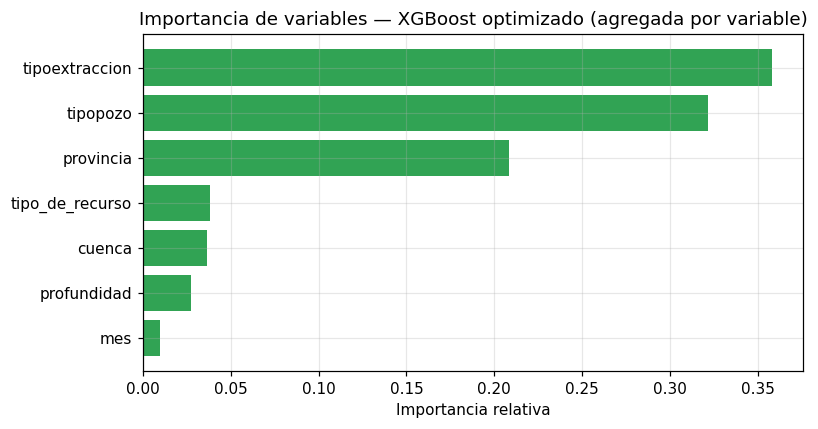

tipoextraccion    0.358
tipopozo          0.322
provincia         0.208
tipo_de_recurso   0.038
cuenca            0.037
profundidad       0.027
mes               0.010


In [15]:
# ── G.4 Importancia de variables del modelo final (agregada a la variable original) ──
pre   = modelo_final.regressor_.named_steps['pre']
names = pre.get_feature_names_out()
imps  = modelo_final.regressor_.named_steps['modelo'].feature_importances_

agg = {c: 0.0 for c in feat_principal}
for f, i in zip(names, imps):
    base = f.split('__', 1)[1]
    for c in feat_principal:
        if base == c or base.startswith(c + '_'):
            agg[c] += float(i); break
imp = pd.Series(agg).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(imp.index, imp.values, color='#31a354')
ax.set_title('Importancia de variables — XGBoost optimizado (agregada por variable)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout(); plt.savefig('figs/fig4_importancia.png', bbox_inches='tight'); plt.show()
print(imp.sort_values(ascending=False).round(3).to_string())

> **Determinantes de la producción (P8).** La importancia agregada (Figura de importancia) confirma la hipótesis del TP1, con una jerarquía clara en tres niveles: **`tipoextraccion`** (≈ 0,36) y **`tipopozo`** (≈ 0,32) dominan ampliamente; **`provincia`** (≈ 0,21) se ubica en un segundo escalón, muy por encima de **`tipo_de_recurso`** (≈ 0,04) y **`cuenca`** (≈ 0,04) —conviene no agruparlas como "provincia/cuenca": provincia pesa más de 5 veces lo que pesa cuenca—; **`profundidad`** (≈ 0,03) y **`mes`** (≈ 0,01) aportan poco. Coincide con lo observado en el EDA: la Surgencia Natural y el desarrollo no convencional de la Cuenca Neuquina concentran los mayores volúmenes. Las correlaciones lineales débiles del TP1 no anticipaban esto porque el efecto de estas variables es **no lineal y por grupos**, algo que solo los modelos basados en árboles capturan.

## H. Análisis de sensibilidad — aporte de la co-producción

Cuantificamos cuánto mejora la predicción al **incluir los fluidos co-producidos** (`prod_gas`, `prod_agua`, `iny_agua`, `tef`). Estas variables se miden el **mismo mes** que `prod_pet`, por lo que **no** están disponibles en el escenario de caracterización de un pozo y su uso predictivo es contemporáneo (cercano al *leakage*). Se reporta como **ablación**, no como modelo principal, para justificar por qué el modelo desplegable se basa en el set estructural.

XGBoost — set estructural (principal)    : R²_test = 0.453
XGBoost — set + co-producción (ablación) : R²_test = 0.761
Ganancia por co-producción               : +0.309 R²


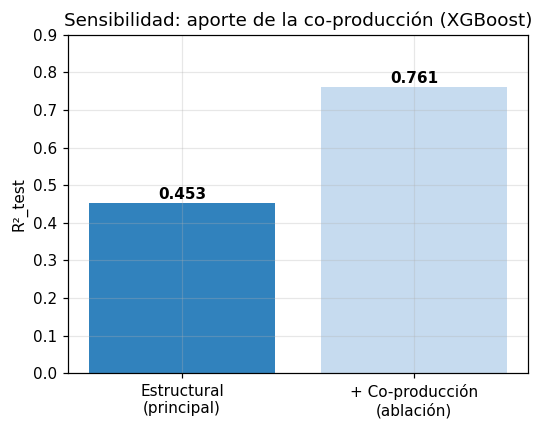

In [16]:
# ── H.1 XGBoost: set estructural vs. set + co-producción ─────────────────────
num_abl = num_principal + num_coproduccion
X_abl = sub[num_abl + cat_principal].copy()

m_abl = construir(modelos['XGBoost'][0], num_abl, cat_principal)
m_abl.fit(X_abl.iloc[idx_tr], y[idx_tr])
r2_abl = r2_score(y[idx_te], m_abl.predict(X_abl.iloc[idx_te]))
r2_pri = tabla.set_index('Modelo').loc['XGBoost', 'R2_test']

print(f'XGBoost — set estructural (principal)    : R²_test = {r2_pri:.3f}')
print(f'XGBoost — set + co-producción (ablación) : R²_test = {r2_abl:.3f}')
print(f'Ganancia por co-producción               : +{r2_abl - r2_pri:.3f} R²')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Estructural\n(principal)', '+ Co-producción\n(ablación)'], [r2_pri, r2_abl],
       color=['#3182bd', '#c6dbef'])
for i, v in enumerate([r2_pri, r2_abl]): ax.text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('R²_test'); ax.set_title('Sensibilidad: aporte de la co-producción (XGBoost)')
ax.set_ylim(0, 0.9)
plt.tight_layout(); plt.savefig('figs/fig5_ablacion.png', bbox_inches='tight'); plt.show()

> **Interpretación.** Los fluidos co-producidos casi **duplican** el R² (de ~0,45 a ~0,76). Es esperable: el corte de agua y la relación gas–petróleo reflejan directamente el estado productivo del pozo. Sin embargo, incorporarlos responde a otra pregunta —"dado que conozco los otros fluidos de este mes, ¿cuánto petróleo salió?"— y **no** a la de caracterización (P7). Por eso el modelo desplegable del TP4 se basa en el **set estructural**, más honesto y de mayor utilidad operativa: el usuario ingresa atributos que conoce *antes* de operar el pozo.

## Cuestionario de interpretación de resultados

> *Nota: los valores numéricos citados corresponden a la última corrida; tras re-ejecutar pueden variar de forma marginal sin alterar las conclusiones.*

**1. ¿Cuál fue el mejor modelo y cambiaría la elección con otra métrica?**
El **XGBoost** domina en las tres métricas de test simultáneamente (mayor R², menor RMSE y menor MAE), por lo que la elección es robusta y **no** cambia al priorizar MAE sobre RMSE: es el mejor en ambas. Optimizado por `GridSearchCV` con validación cruzada agrupada, su R²_test sube de **0,453 a 0,459** y su RMSE de **436,3 a 434,0 m³/mes**; es el que se **adopta como modelo desplegable del TP4**. La mejora es real pero **modesta**, coherente con el `learning_rate` bajo (0,05) elegido por la búsqueda para priorizar generalización sobre ajuste agresivo. Un matiz que confirma la lectura anterior sobre RMSE vs. MAE: el MAE del modelo optimizado (105,84) es marginalmente **peor** que el del XGBoost por defecto (105,51), mientras el RMSE sí mejora. Esto indica que la optimización corrigió específicamente los **errores grandes** (la cola de Vaca Muerta, que pesa más en el RMSE) a costa de una pérdida ínfima en el error típico del pozo (que pesa más en el MAE) — exactamente el tipo de trade-off que la diferencia entre ambas métricas anticipaba. Si el objetivo de negocio fuera la producción total agregada, convendría ponderar más el RMSE (y por tanto preferir el modelo optimizado sin dudar); para el pozo típico, el MAE es más representativo y la ganancia de optimizar es marginal.

**2. ¿Hubo sobreajuste o subajuste? Relación con sesgo–varianza.**
Sí, en ambos extremos. La **familia lineal subajusta (alto sesgo)**: R²_train ≈ R²_test ≈ 0,24, sin brecha pero con desempeño pobre —el modelo es demasiado simple para relaciones no lineales por grupos—. **Random Forest y KNN sobreajustan (alta varianza)**: R²_train de 0,78–0,99 frente a R²_test ≈ 0,40, una brecha amplia. Aquí conviene ser honesto: esa brecha combina dos causas —la varianza propia de esos modelos **y** el hecho de que se entrenaron con 30 k filas frente a las 211 k de XGBoost—, por lo que no es una comparación de igual a igual en volumen de datos. Mitigación aplicada/posible: para RF, limitar `max_depth`, subir `min_samples_leaf` o aumentar el train; para KNN, subir `k`. El **XGBoost** —entrenado con el mismo volumen que los lineales— ya equilibra sesgo y varianza (brecha pequeña) gracias a la regularización, la profundidad acotada y el submuestreo de filas/columnas; la búsqueda de hiperparámetros con `GroupKFold` afinó ese equilibrio y la validación cruzada agrupada confirma la estabilidad (R² CV ≈ R² hold-out).

**3. ¿Qué factores del dominio explican el desempeño? ¿Quedan patrones sin capturar?**
El parque es **estructuralmente heterogéneo**: conviven convencionales maduros de bajo caudal con no convencionales de Vaca Muerta de altísima productividad, generando distribuciones multimodales que los modelos lineales no representan y los árboles sí. Por eso las variables de mayor importancia son categóricas —**método de extracción y tipo de pozo** en primer lugar, **provincia** en un segundo escalón claramente por encima de **tipo de recurso** y **cuenca**—. El **análisis de residuos avanzado** confirma que aún quedan patrones sin capturar: los residuos **no son normales** (Shapiro-Wilk p ≈ 5,3 × 10⁻⁸⁹, muy por debajo de 0,05) y son **heterocedásticos** (su desvío estándar se dispara en el último decil de predicción, hasta un orden de magnitud por encima de los deciles intermedios, según la Figura de residuos por decil); los pozos de mayor producción concentran los residuos más grandes —su volumen depende de factores ausentes del dataset (calidad de la roca, diseño de fractura, presión de reservorio)—. Incorporar variables geológicas y de completación, o la historia temporal del pozo (curva de declino), sería la vía para reducir ese error residual.

## Conclusiones

Sobre el corpus depurado en el TP1 se construyó un marco experimental riguroso para predecir la producción mensual de petróleo de pozos productores. La partición **agrupada por pozo** (`GroupShuffleSplit` + `GroupKFold`) evitó el *data leakage* de panel, y la transformación **`log1p`** neutralizó la asimetría severa del target (skewness 9,09 → 0,12). Entre seis algoritmos, el **XGBoost** resultó el mejor (R²_test ≈ 0,45; superando a la regresión lineal —que subajusta, R² ≈ 0,24— y a Random Forest/KNN —que sobreajustan, R²_train ≈ 0,78–0,99 vs. R²_test ≈ 0,40—); su versión **optimizada por `GridSearchCV`** con validación cruzada agrupada elevó el R²_test a **0,459** (RMSE ≈ 434 m³/mes) y se adoptó como **modelo desplegable del TP4**, serializado con `joblib` en un archivo de solo **8 MB** —un tamaño cómodo para el despliegue en Streamlit, a diferencia del riesgo que anticipábamos con ensambles más pesados—. Las variables determinantes son, en orden claro de importancia, el **método de extracción y el tipo de pozo** primero, la **provincia** en un segundo escalón, y muy por detrás el **tipo de recurso** y la **cuenca**, coherente con la heterogeneidad del parque productivo nacional. El análisis de sensibilidad mostró que los fluidos co-producidos elevan el R² a ~0,76, pero por su naturaleza contemporánea se reservan como ablación: el modelo desplegable usa el **set estructural**, más honesto y usable con los datos que un usuario conoce antes de operar el pozo. El análisis de residuos avanzado documentó no-normalidad (Shapiro-Wilk p ≈ 5,3×10⁻⁸⁹) y heterocedasticidad marcada en la cola alta, señalando como trabajo futuro la incorporación de variables geológicas y de completación.